<a href="https://colab.research.google.com/github/ada-xo-xo/dsrp/blob/main/DSRP_2026_Adanna_Oji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#from scipy.stats import spearmanr, kruskal

df = pd.read_csv('/content/nyt_bestsellers_combined (1).csv')
df.head(10)

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5
5,1931,1931-11-16,1,2878,MAID IN WAITING,John Galsworthy,1931,9,1931-11-16,1,1
6,1931,1931-11-16,2,7031,TWO PEOPLE,A. A. Milne,1931,4,1931-11-16,2,2
7,1931,1931-11-16,3,413,AMERICAN BEAUTY,Edna Ferber,1931,2,1931-11-16,3,2
8,1931,1931-11-16,4,859,BROOME STAGES,Clemance Dane,1931,3,1931-11-16,4,2
9,1931,1931-11-16,5,4235,SPARKS FLY UPWARD,Oliver LaFarge,1931,1,1931-11-16,5,5


In [ ]:
#This is just helping me explore general things about the dataset
print('General Info:\n', df.info())
print('Shape:\n', df.shape)
total_duplicates = df.duplicated().sum()
print("Total duplicate rows:\n", total_duplicates)


#There is missing data but not sure if I want to remove it because 1: the author seems to be in the title column instead
#2:I won't be focusing on authors and titles at the moment so it won't mess up my data
bool_series = pd.isnull(df["author"])
missing_data = df[bool_series]
print('Rows with missing data:\n', missing_data['author'])

#I wanted to see if each title was only associated with one 1 title ID, however there seems to be multiple editions of the same book under different title ID's.
#I think I will group by title since they are still technically the same book.
title_duplicates = df['title'].duplicated().sum()
print("Total title duplicate rows:", title_duplicates)

title_id_duplicates = df['title_id'].duplicated().sum()
print("Total title ID duplicate rows:", title_id_duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60386 entries, 0 to 60385
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         60386 non-null  int64 
 1   week         60386 non-null  object
 2   rank         60386 non-null  int64 
 3   title_id     60386 non-null  int64 
 4   title        60386 non-null  object
 5   author       60376 non-null  object
 6   pub_year     60386 non-null  int64 
 7   total_weeks  60386 non-null  int64 
 8   first_week   60386 non-null  object
 9   debut_rank   60386 non-null  int64 
 10  best_rank    60386 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 5.1+ MB
General Info:
 None
Shape:
 (60386, 11)
Total duplicate rows:
 0
Rows with missing data:
 161     NaN
579     NaN
586     NaN
594     NaN
595     NaN
606     NaN
1139    NaN
1739    NaN
1754    NaN
1847    NaN
Name: author, dtype: object
Total title duplicate rows: 53214
Total title ID duplicate rows: 52955

In [ ]:
#I converted date columns
df["week"] = pd.to_datetime(df["week"], errors="coerce")
df["first_week"] = pd.to_datetime(df["first_week"], errors="coerce")

#Created a 'Start of Decade' column
df['start_of_decade'] = (df['year'] // 10) * 10

#Then converted to string like "1990s" to make a decade column
df['decade'] = df['start_of_decade'].astype(str) + "s"

In [ ]:
#Since I am focusing on rank and total weeks I don't need to have multiple of the same title
df2 = df.drop_duplicates(subset=['title_id'])

#I will be focusing on decades for the most part so I will remove data from the 2020s beause the dataset doesn't have data for the rest of the decade
df2.drop(df2[df2['start_of_decade'] == 2020].index, inplace=True)


/tmp/ipykernel_10183/653227456.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(df2[df2['start_of_decade'] == 2020].index, inplace=True)


In [ ]:
#Creating a visualization based on the research question: How has the average total length of time a book stays on the bestseller list changed over the decades?
#Steps: 1. Drop all columns but the total weeks and year.
#2. Group by decade, find mean of weeks
#3. Create scatter plot then go from there

#df2=df.drop(columns=['best_rank','debut_rank','pub_year','author','title','title_id','rank','week'])
df_1930s = df2[df2["year"] < 1940]
mean_30s= df_1930s['total_weeks'].mean()

df_1940s = df2[df2["year"] .between(1940, 1949)]
mean_40s= df_1940s['total_weeks'].mean()

df_1950s = df2[df2["year"] .between(1950, 1959)]
mean_50s= df_1950s['total_weeks'].mean()

df_1960s = df2[df2["year"] .between(1960, 1969)]
mean_60s= df_1960s['total_weeks'].mean()

df_1970s = df2[df2["year"] .between(1970, 1979)]
mean_70s= df_1970s['total_weeks'].mean()

df_1980s = df2[df2["year"] .between(1980, 1989)]
mean_80s= df_1980s['total_weeks'].mean()

df_1990s = df2[df2["year"] .between(1990, 1999)]
mean_90s= df_1990s['total_weeks'].mean()

df_2000s = df2[df2["year"] .between(2000, 2009)]
mean_00s= df_2000s['total_weeks'].mean()

df_2010s = df2[df2["year"] .between(2010, 2019)]
mean_10s= df_2010s['total_weeks'].mean()

#Will exclude 2020 because the dataset doesn't have data for the rest of the decade

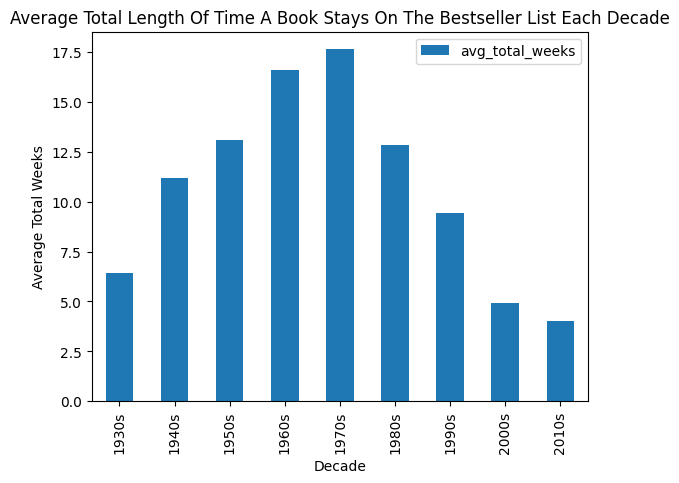

In [ ]:
avg_time_per_decade_df = pd.DataFrame({
        "decade": ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s'],
        "avg_total_weeks": [mean_30s,mean_40s,mean_50s,mean_60s,mean_70s,mean_80s,mean_90s,mean_00s,mean_10s]
     })

avg_time_per_decade_df.plot.bar(x='decade', y='avg_total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Total Weeks')
plt.show()

In [ ]:
avg_time_per_decade_df.groupby('decade')['avg_total_weeks'].agg(
    ['count', 'mean', 'median', 'std']
).round()

,count,mean,median,std
decade,,,,
1930s,1,6.0,6.0,NaN
1940s,1,11.0,11.0,NaN
1950s,1,13.0,13.0,NaN
1960s,1,17.0,17.0,NaN
1970s,1,18.0,18.0,NaN
1980s,1,13.0,13.0,NaN
1990s,1,9.0,9.0,NaN
2000s,1,5.0,5.0,NaN
2010s,1,4.0,4.0,NaN


In [ ]:
#I wanted to check the values
print(avg_time_per_decade_df)

  decade  avg_total_weeks
0  1930s         6.452785
1  1940s        11.174004
2  1950s        13.088235
3  1960s        16.591667
4  1970s        17.648148
5  1980s        12.850082
6  1990s         9.416370
7  2000s         4.945103
8  2010s         4.022066


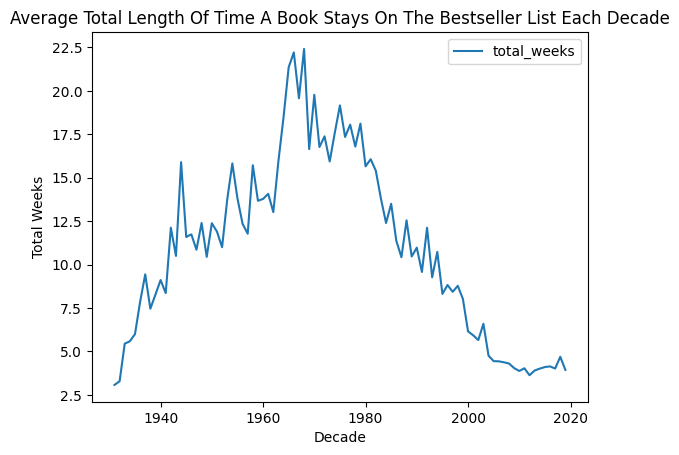

In [ ]:
#I wanted to see if the trend was more apparent by year but there is no obvious trend by year
all_years_df=df2.groupby('year').mean(numeric_only=True)
all_years_df = all_years_df.reset_index()

all_years_df.plot(x='year', y='total_weeks')
plt.title('Average Total Length Of Time A Book Stays On The Bestseller List Each Decade')
plt.xlabel('Decade')
plt.ylabel('Total Weeks')
plt.show()

In [ ]:
print(df2[['year', 'total_weeks']].corr())
print(all_years_df[['year', 'total_weeks']].corr())

                year  total_weeks
year         1.00000     -0.25876
total_weeks -0.25876      1.00000
                year  total_weeks
year         1.00000     -0.35088
total_weeks -0.35088      1.00000


In [ ]:
#I am grouping the data, this will help me make more visualizations
avg_rank_df=df2.groupby('decade').mean(numeric_only=True)
avg_rank_df

,year,rank,title_id,pub_year,total_weeks,debut_rank,best_rank,start_of_decade
decade,,,,,,,,
1930s,1935.164649,4.774818,3775.970944,1935.164649,6.452785,4.774818,3.772397,1930.0
1940s,1945.524109,9.716981,3927.662474,1945.524109,11.174004,4.356394,6.903564,1940.0
1950s,1954.349845,13.137771,4081.961300,1954.349845,13.088235,11.233746,9.185759,1950.0
1960s,1963.597222,10.986111,4023.544444,1963.597222,16.591667,9.405556,7.105556,1960.0
1970s,1974.820988,9.416667,4021.975309,1974.820988,17.648148,6.070988,5.524691,1970.0
1980s,1984.894563,10.677100,3763.489292,1984.894563,12.850082,6.962109,6.901153,1980.0
1990s,1994.730724,9.874259,3373.291815,1994.730724,9.416370,8.651246,7.080664,1990.0
2000s,2004.981285,7.625702,3517.902682,2004.981285,4.945103,7.839676,7.141609,2000.0
2010s,2014.351555,6.958877,3695.846540,2014.351555,4.022066,8.322969,6.805416,2010.0


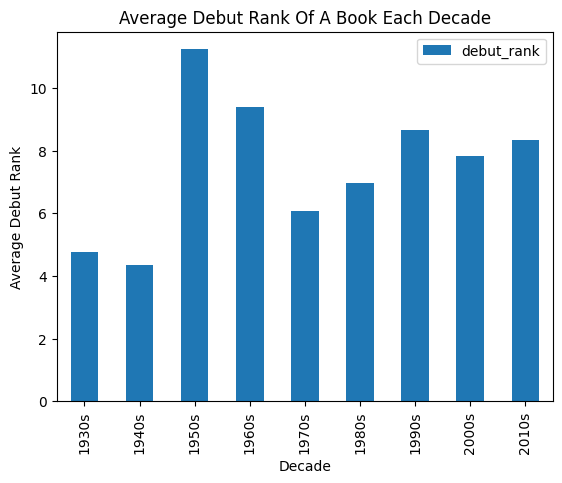

In [ ]:
avg_rank_df_reset = avg_rank_df.reset_index()
avg_rank_df_reset.plot.bar(x='decade', y='debut_rank')
plt.title('Average Debut Rank Of A Book Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Debut Rank')
plt.show()

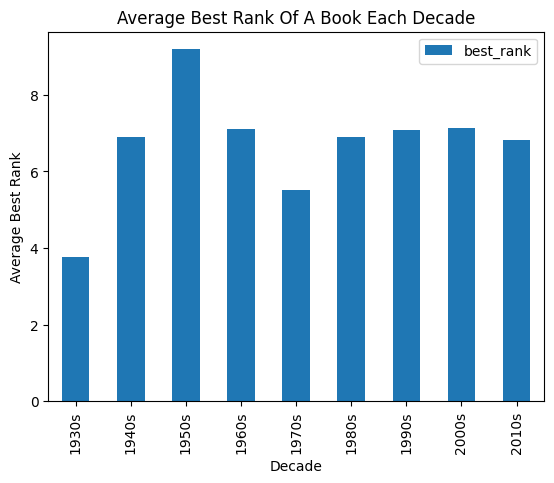

In [ ]:
avg_rank_df_reset.plot.bar(x='decade', y='best_rank')
plt.title('Average Best Rank Of A Book Each Decade')
plt.xlabel('Decade')
plt.ylabel('Average Best Rank')
plt.show()

In [ ]:
rank1_df=df2[df2['best_rank'] == 1]
grouped_rank1_df=rank1_df.groupby('decade').count()
grouped_rank1_df_reset = grouped_rank1_df.reset_index()
grouped_rank1_df_reset

,decade,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank,start_of_decade
0,1930s,74,74,74,74,74,74,74,74,74,74,74,74
1,1940s,59,59,59,59,59,59,59,59,59,59,59,59
2,1950s,35,35,35,35,35,35,35,35,35,35,35,35
3,1960s,31,31,31,31,31,31,31,31,31,31,31,31
4,1970s,46,46,46,46,46,46,46,46,46,46,46,46
5,1980s,79,79,79,79,79,79,79,79,79,79,79,79
6,1990s,99,99,99,99,99,99,99,99,99,99,99,99
7,2000s,220,220,220,220,220,220,220,220,220,220,220,220
8,2010s,306,306,306,306,306,306,306,306,306,306,306,306


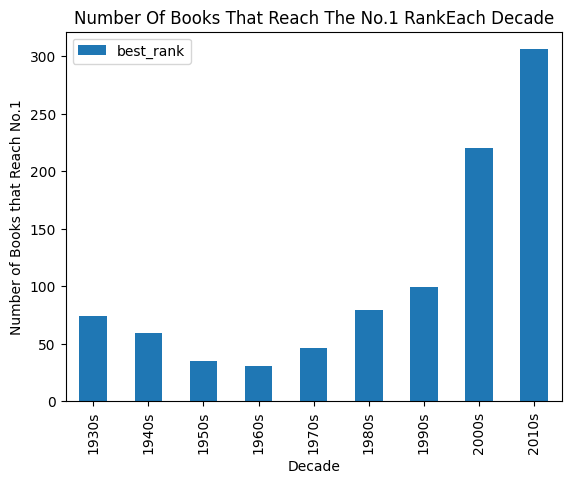

In [ ]:
grouped_rank1_df_reset.plot.bar(x='decade', y='best_rank')
plt.title('Number Of Books That Reach The No.1 RankEach Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Books that Reach No.1')
plt.show()

In [ ]:
rankcount_1930s_df=df[df['start_of_decade'] == 1930]
rankcount_1930s_df2=rankcount_1930s_df.groupby('rank').count()

rankcount_1940s_df=df[df['start_of_decade'] == 1940]
rankcount_1940s_df2=rankcount_1940s_df.groupby('rank').count()

rankcount_1950s_df=df[df['start_of_decade'] == 1950]
rankcount_1950s_df2=rankcount_1950s_df.groupby('rank').count()

rankcount_1960s_df=df[df['start_of_decade'] == 1960]
rankcount_1960s_df2=rankcount_1960s_df.groupby('rank').count()

rankcount_1970s_df=df[df['start_of_decade'] == 1970]
rankcount_1970s_df2=rankcount_1970s_df.groupby('rank').count()

rankcount_1980s_df=df[df['start_of_decade'] == 1980]
rankcount_1980s_df2=rankcount_1980s_df.groupby('rank').count()

rankcount_1990s_df=df[df['start_of_decade'] == 1990]
rankcount_1990s_df2=rankcount_1990s_df.groupby('rank').count()

rankcount_2000s_df=df[df['start_of_decade'] == 2000]
rankcount_2000s_df2=rankcount_2000s_df.groupby('rank').count()

rankcount_2010s_df=df[df['start_of_decade'] == 2010]
rankcount_2010s_df2=rankcount_2010s_df.groupby('rank').count()

final_rankings_per_decade_df = pd.concat([rankcount_1930s_df2['title'], rankcount_1940s_df2['title'], rankcount_1950s_df2['title'], rankcount_1960s_df2['title'], rankcount_1970s_df2['title'], rankcount_1980s_df2['title'], rankcount_1990s_df2['title'], rankcount_2000s_df2['title'], rankcount_2010s_df2['title']], axis=1)
final_rankings_per_decade_df.columns = ['1930s','1940s','1950s','1960s','1970s','1980s','1990s','2000s','2010s']
#final_rankings_per_decade_df = final_rankings_per_decade_df.reset_index()


final_rankings_per_decade_df

,1930s,1940s,1950s,1960s,1970s,1980s,1990s,2000s,2010s
rank,,,,,,,,,
1,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
2,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
3,424.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
4,312.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
5,312.0,522.0,519.0,518.0,509.0,522,521.0,519.0,518.0
6,291.0,342.0,519.0,518.0,509.0,522,521.0,519.0,518.0
7,232.0,232.0,519.0,518.0,509.0,522,521.0,519.0,518.0
8,176.0,225.0,519.0,518.0,509.0,522,521.0,519.0,518.0
9,3.0,225.0,519.0,518.0,509.0,522,521.0,519.0,518.0


In [ ]:
df_transposed = final_rankings_per_decade_df.transpose()
df_transposed= df_transposed.reset_index()
df_transposed

rank,index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,1930s,424.0,424.0,424.0,312.0,312.0,291.0,232.0,176.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1940s,522.0,522.0,522.0,522.0,522.0,342.0,232.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,225.0,NaN,NaN
2,1950s,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,518.0,NaN,NaN
3,1960s,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,161.0,161.0,161.0,161.0,161.0,157.0,NaN,NaN
4,1970s,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,509.0,108.0,108.0,108.0,108.0,108.0,NaN,NaN,NaN
5,1980s,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,522.0,57.0,10.0,1.0
6,1990s,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,521.0,95.0,15.0,NaN
7,2000s,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,519.0,170.0,1.0,NaN
8,2010s,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,518.0,220.0,NaN,NaN


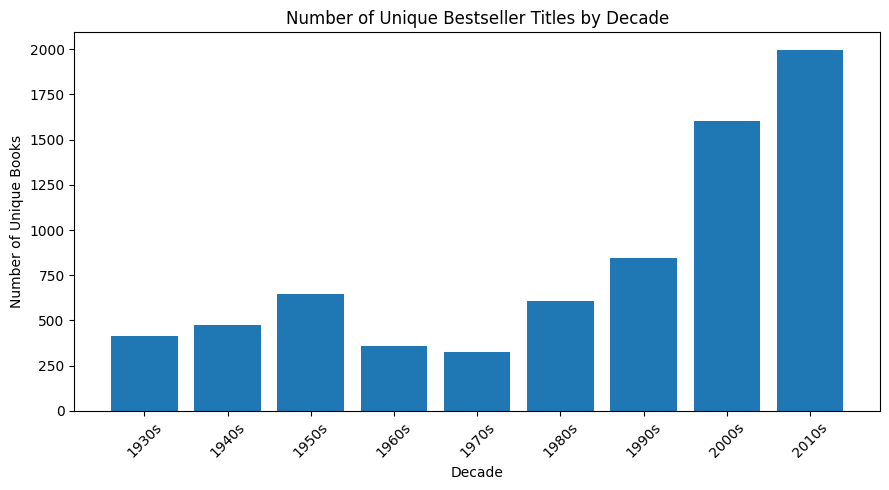

In [ ]:
book_counts = (
df2.groupby(["start_of_decade", "decade"])
.size()
.reset_index(name="book_count")
.sort_values("start_of_decade")
)
plt.figure(figsize=(9, 5))
plt.bar(book_counts["decade"], book_counts["book_count"])
plt.title("Number of Unique Bestseller Titles by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Unique Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

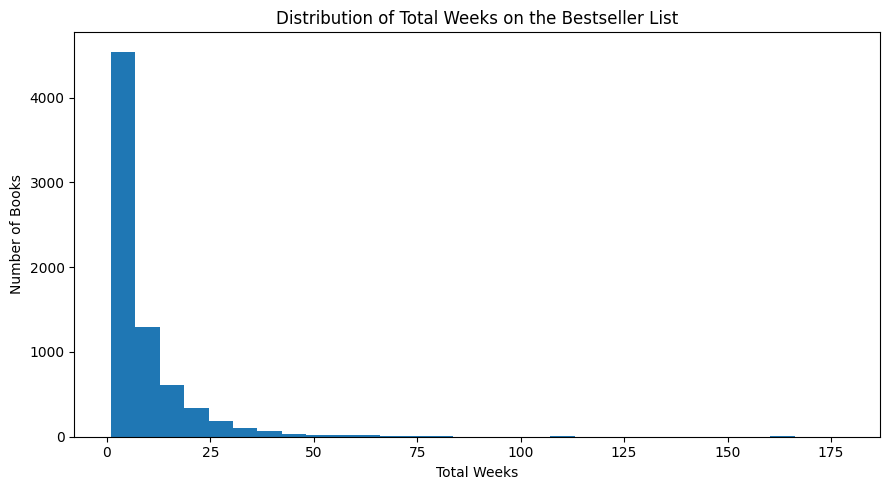

count    60386.000000
mean        23.583115
std         25.941677
min          1.000000
25%          8.000000
50%         16.000000
75%         29.000000
max        178.000000
Name: total_weeks, dtype: float64


In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df2["total_weeks"], bins=30)
plt.title("Distribution of Total Weeks on the Bestseller List")
plt.xlabel("Total Weeks")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()
print(df["total_weeks"].describe())

/tmp/ipykernel_10183/280059571.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=decade_order, showfliers=False)


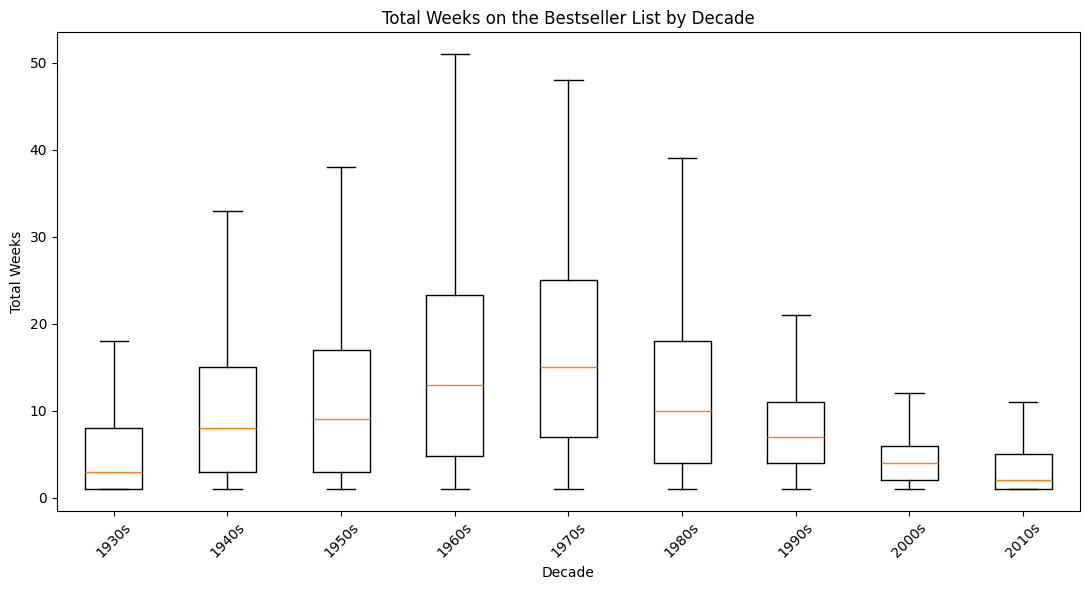

In [31]:
decade_order = (
df2[["start_of_decade", "decade"]]
.drop_duplicates()
.sort_values("start_of_decade")["decade"]
.tolist()
)

box_data = [
df2.loc[df2["decade"] == decade, "total_weeks"]
for decade in decade_order
]

plt.figure(figsize=(11, 6))
plt.boxplot(box_data, labels=decade_order, showfliers=False)
plt.title("Total Weeks on the Bestseller List by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Weeks")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

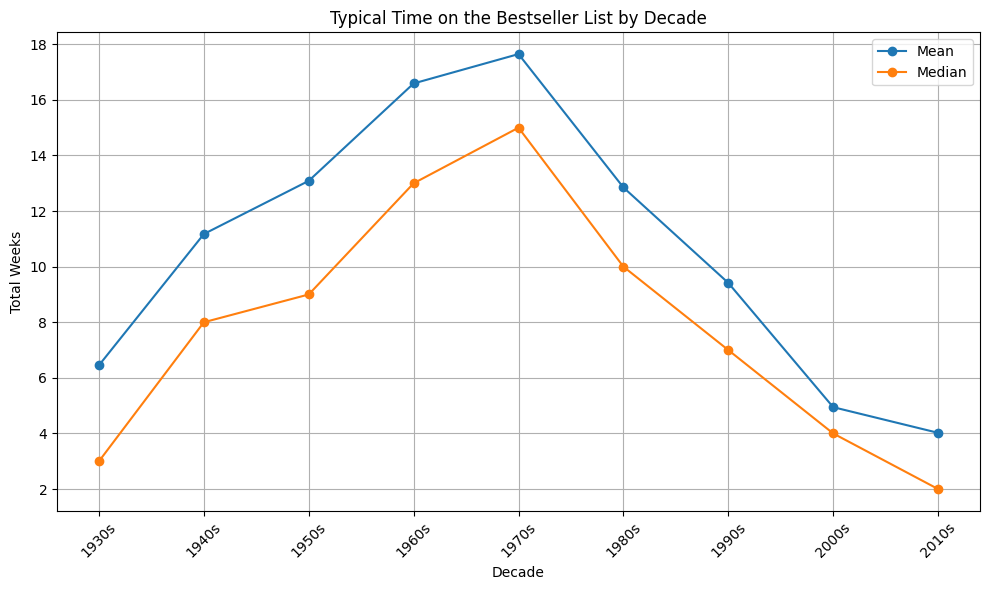

,start_of_decade,decade,book_count,mean_weeks,median_weeks,std_weeks
0,1930,1930s,413,6.452785,3.0,9.425529
1,1940,1940s,477,11.174004,8.0,11.842148
2,1950,1950s,646,13.088235,9.0,14.924511
3,1960,1960s,360,16.591667,13.0,14.861381
4,1970,1970s,324,17.648148,15.0,14.040619
5,1980,1980s,607,12.850082,10.0,10.692010
6,1990,1990s,843,9.416370,7.0,12.924817
7,2000,2000s,1603,4.945103,4.0,7.234142
8,2010,2010s,1994,4.022066,2.0,7.132993


In [33]:
decade_summary = (
df2.groupby(["start_of_decade", "decade"])["total_weeks"]
.agg(book_count="count", mean_weeks="mean",
median_weeks="median", std_weeks="std")
.reset_index()
.sort_values("start_of_decade")
)
plt.figure(figsize=(10, 6))
plt.plot(decade_summary["decade"], decade_summary["mean_weeks"],
marker="o", label="Mean")
plt.plot(decade_summary["decade"], decade_summary["median_weeks"],
marker="o", label="Median")
plt.title("Typical Time on the Bestseller List by Decade")
plt.xlabel("Decade")
plt.ylabel("Total Weeks")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
display(decade_summary)

/tmp/ipykernel_10183/798585239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["ten_plus_weeks"] = df2["total_weeks"] >= 10


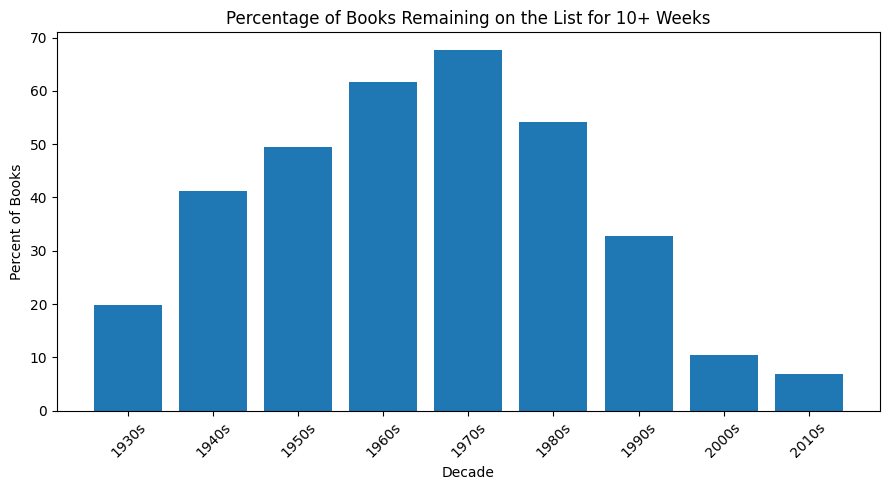

In [65]:
df2["ten_plus_weeks"] = df2["total_weeks"] >= 10
ten_plus = (
df2.groupby(["start_of_decade", "decade"])["ten_plus_weeks"]
.mean()
.mul(100)
.reset_index(name="percent_10_plus")
.sort_values("start_of_decade")
)
plt.figure(figsize=(9, 5))
plt.bar(ten_plus["decade"], ten_plus["percent_10_plus"])
plt.title("Percentage of Books Remaining on the List for 10+ Weeks")
plt.xlabel("Decade")
plt.ylabel("Percent of Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

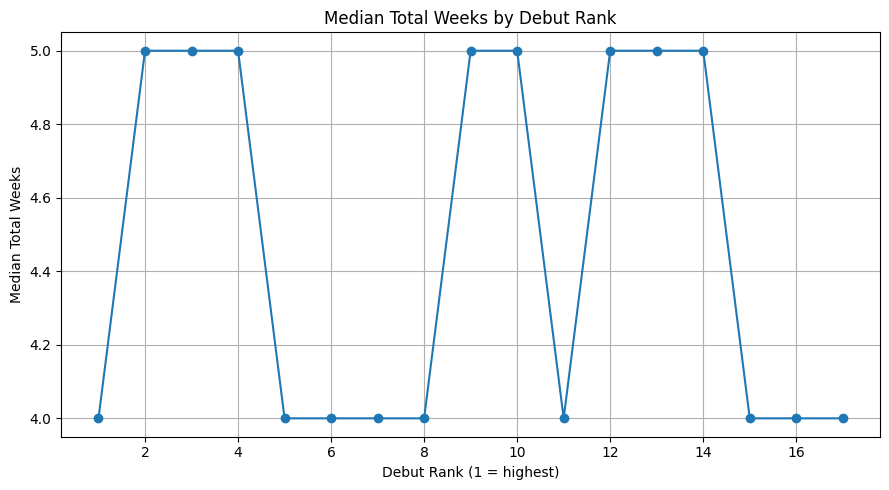

In [66]:
rank_summary = (
df2.groupby("debut_rank")["total_weeks"]
.agg(mean_weeks="mean", median_weeks="median", book_count="count")
.reset_index()
)
plt.figure(figsize=(9, 5))
plt.plot(rank_summary["debut_rank"], rank_summary["median_weeks"], marker="o")
plt.title("Median Total Weeks by Debut Rank")
plt.xlabel("Debut Rank (1 = highest)")
plt.ylabel("Median Total Weeks")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_10183/3727067467.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["reached_number_one"] = df2["best_rank"] == 1


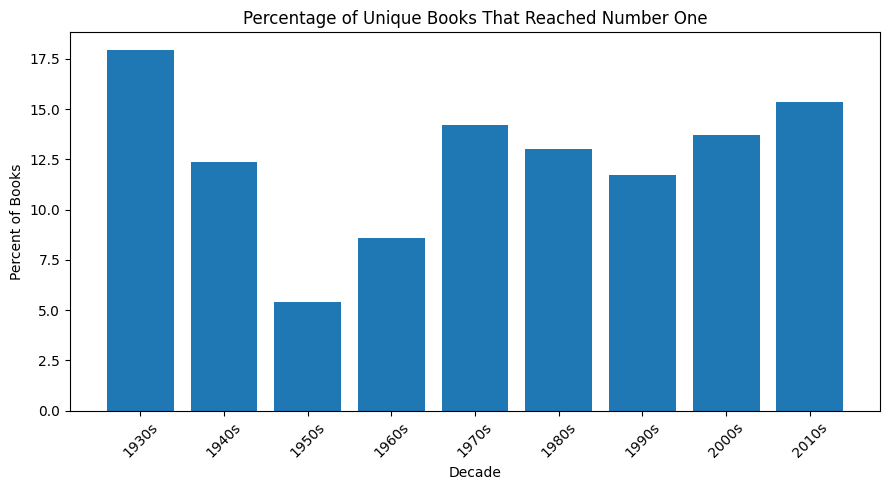

In [68]:
df2["reached_number_one"] = df2["best_rank"] == 1
number_one_rate = (
df2.groupby(["start_of_decade", "decade"])["reached_number_one"]
.mean()
.mul(100)
.reset_index(name="percent_reached_number_one")
.sort_values("start_of_decade")
)
plt.figure(figsize=(9, 5))
plt.bar(number_one_rate["decade"],
number_one_rate["percent_reached_number_one"])
plt.title("Percentage of Unique Books That Reached Number One")
plt.xlabel("Decade")
plt.ylabel("Percent of Books")
plt.xticks(rotation=45)
plt.tight_layout()

In [69]:
rho, p_value = spearmanr(
boks_complete["debut_year"],
books_complete["total_weeks"],
nan_policy="omit"
)
print("Spearman rho:", round(rho, 3))
print("P-value:", p_value)

NameError: name 'spearmanr' is not defined